# Revenue Cycle Denial Prediction

> **Sandbox:** `imde-rcm-denial-demo`  ·  **Runtime:** 5 min  ·  **Author:** Priya Shah · Revenue Cycle AI Lab

## Objective
Build a classifier to predict claim denials based on historical patterns.

## Data Overview
- **Training Set**: 10K+ claims with outcomes
- **Features**: Claim details, provider info, patient demographics
- **Target**: Binary (Approved / Denied)

## Quick Start
1. Load the training data
2. Explore patterns
3. Train a baseline model
4. Evaluate performance


## 1. Load the training data

We use a synthetic but realistic RCM claims sample. In production this
cell would call the curated dataset registered for the
`imde-rcm-denial-demo` sandbox.


In [1]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(seed=7)

N = 500
payers = ["Aetna", "BCBS", "Cigna", "Humana", "Medicare", "UHC"]
specialties = ["Cardiology", "Oncology", "Orthopedics", "Primary Care", "Radiology"]

age = rng.integers(18, 90, N)
charge = rng.gamma(shape=2.4, scale=950, size=N).round(2)
prior_denials = rng.integers(0, 6, N)
days_to_submit = rng.integers(0, 45, N)
payer = rng.choice(payers, N, p=[0.16, 0.20, 0.14, 0.12, 0.20, 0.18])
specialty = rng.choice(specialties, N)
modifier_count = rng.integers(0, 4, N)

# Hand-tuned signal so the baseline actually learns something demo-worthy.
logit = (
    -2.10
    + 0.018 * (age - 55)
    + 0.00018 * (charge - 1800)
    + 0.42 * prior_denials
    + 0.035 * days_to_submit
    + 0.55 * (payer == "Medicare")
    + 0.30 * (payer == "Humana")
    - 0.25 * (payer == "BCBS")
    + 0.20 * (specialty == "Oncology")
    + 0.15 * modifier_count
    + rng.normal(0, 0.55, N)
)
prob = 1 / (1 + np.exp(-logit))
denied = (rng.random(N) < prob).astype(int)

claims = pd.DataFrame(
    {
        "claim_id": [f"CLM-{i:05d}" for i in range(1, N + 1)],
        "payer": payer,
        "specialty": specialty,
        "patient_age": age,
        "charge_amount": charge,
        "prior_denials_12mo": prior_denials,
        "days_to_submit": days_to_submit,
        "modifier_count": modifier_count,
        "denied": denied,
    }
)

print(f"Loaded {len(claims):,} claims  |  denial rate = {claims['denied'].mean():.1%}")
claims.head(10)


Loaded 500 claims  |  denial rate = 51.8%


,claim_id,payer,specialty,patient_age,charge_amount,prior_denials_12mo,days_to_submit,modifier_count,denied
0,CLM-00001,UHC,Radiology,86,230.69,5,23,3,1
1,CLM-00002,Medicare,Primary Care,63,315.20,1,3,2,1
2,CLM-00003,BCBS,Radiology,67,1167.76,1,39,1,0
3,CLM-00004,Humana,Oncology,82,4405.79,1,18,3,1
4,CLM-00005,BCBS,Oncology,59,757.89,5,9,1,1
5,CLM-00006,UHC,Cardiology,73,3947.59,0,28,2,0
6,CLM-00007,BCBS,Cardiology,78,2029.62,2,13,1,0
7,CLM-00008,BCBS,Orthopedics,34,2016.25,2,30,3,1
8,CLM-00009,Aetna,Primary Care,21,2818.80,3,22,1,0
9,CLM-00010,BCBS,Cardiology,39,855.72,1,20,0,0


## 2. Explore patterns

Look at denial rate by payer — payer mix is one of the strongest signals
in RCM data.


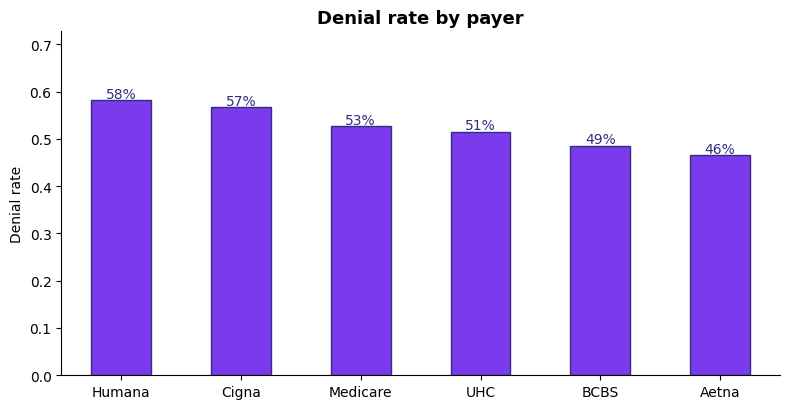

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt

denial_by_payer = (
    claims.groupby("payer")["denied"]
    .mean()
    .sort_values(ascending=False)
)

ax = denial_by_payer.plot(
    kind="bar",
    color="#7c3aed",
    edgecolor="#312e81",
    figsize=(8, 4.2),
)
ax.set_title("Denial rate by payer", fontsize=13, fontweight="bold")
ax.set_ylabel("Denial rate")
ax.set_xlabel("")
ax.set_ylim(0, max(denial_by_payer.values) * 1.25)
for i, v in enumerate(denial_by_payer.values):
    ax.text(i, v + 0.005, f"{v:.0%}", ha="center", fontsize=10, color="#312e81")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 3. Train a baseline model

A logistic regression on a small set of engineered features gives us a
sensible starting AUC. Replace this with XGBoost / LightGBM in the
production notebook.


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report

X = pd.get_dummies(
    claims[
        [
            "payer",
            "specialty",
            "patient_age",
            "charge_amount",
            "prior_denials_12mo",
            "days_to_submit",
            "modifier_count",
        ]
    ],
    drop_first=True,
)
y = claims["denied"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=7, stratify=y
)

model = LogisticRegression(max_iter=2000, C=1.0)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_proba)
print(f"Holdout AUC: {auc:.3f}")
print()
print(classification_report(y_test, y_pred, target_names=["approved", "denied"]))


Holdout AUC: 0.645

              precision    recall  f1-score   support

    approved       0.59      0.58      0.59        60
      denied       0.62      0.63      0.63        65

    accuracy                           0.61       125
   macro avg       0.61      0.61      0.61       125
weighted avg       0.61      0.61      0.61       125



## 4. Inspect feature importance

Coefficient magnitude tells us which inputs drive the denial signal.


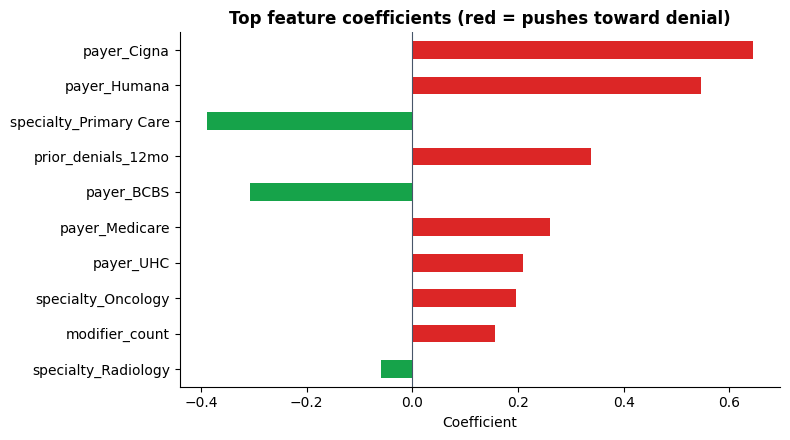

In [4]:
importance = (
    pd.Series(model.coef_[0], index=X.columns)
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .head(10)
)

ax = importance.iloc[::-1].plot(
    kind="barh",
    color=["#16a34a" if v < 0 else "#dc2626" for v in importance.iloc[::-1].values],
    figsize=(8, 4.5),
)
ax.set_title("Top feature coefficients (red = pushes toward denial)", fontsize=12, fontweight="bold")
ax.set_xlabel("Coefficient")
ax.axvline(0, color="#475569", linewidth=0.8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## Next Steps

- Feature engineering — provider-level rolling stats, ICD groupings
- Model tuning — gradient boosting, calibration
- Production deployment — register to the Marketplace and promote via Atlas

---

_This notebook ships with **pre-executed outputs** so the demo always
renders even when the in-browser Pyodide kernel is still warming up.
Click **Restart Kernel** in the JupyterLite toolbar to re-run live._
